# Lab 2: Classification Using KNN and RNN Algorithms

**Student:** Minh Le  
**Course:** 2026 Fall - Advanced Big Data and Data Mining (MSCS-634-M50) - Full Term  
**Dataset:** Wine Dataset from scikit-learn

## Purpose and experimental design

This notebook compares K-Nearest Neighbors (KNN) and Radius Neighbors (RNN) on the Wine dataset. Both algorithms use distances, but KNN always selects a fixed number of neighbors while RNN selects every training observation within a fixed radius. We use one stratified 80/20 train-test split (`random_state=42`) for every experiment so that the comparisons are reproducible and fair.

> **Scale decision:** The features are intentionally left unscaled. The assigned RNN radii (350–600) only make sense on the dataset's original scale. This also creates an important lesson: high-magnitude features such as `proline` dominate Euclidean distance. In a production modeling workflow, scaling and retuning both `k` and `radius` would normally be essential.

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

## 1. Load and explore the Wine dataset

In [2]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name="target")
class_names = dict(enumerate(wine.target_names))
data = X.assign(target=y, class_name=y.map(class_names))

print(f"Observations: {X.shape[0]}")
print(f"Features: {X.shape[1]}")
print(f"Classes: {len(wine.target_names)} ({', '.join(wine.target_names)})")
display(data.head())

Observations: 178
Features: 13
Classes: 3 (class_0, class_1, class_2)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [3]:
feature_summary = X.agg(["min", "mean", "max", "std"]).T
class_distribution = (
    data["class_name"]
    .value_counts()
    .rename_axis("class")
    .to_frame("count")
)
class_distribution["percent"] = (
    100 * class_distribution["count"] / len(data)
).round(2)

print(f"Total missing values: {data.isna().sum().sum()}")
display(feature_summary)
display(class_distribution)

Total missing values: 0


,min,mean,max,std
alcohol,11.03,13.000618,14.83,0.811827
malic_acid,0.74,2.336348,5.80,1.117146
ash,1.36,2.366517,3.23,0.274344
alcalinity_of_ash,10.60,19.494944,30.00,3.339564
magnesium,70.00,99.741573,162.00,14.282484
total_phenols,0.98,2.295112,3.88,0.625851
flavanoids,0.34,2.029270,5.08,0.998859
nonflavanoid_phenols,0.13,0.361854,0.66,0.124453
proanthocyanins,0.41,1.590899,3.58,0.572359
color_intensity,1.28,5.058090,13.00,2.318286


,count,percent
class,,
class_1,71,39.89
class_0,59,33.15
class_2,48,26.97


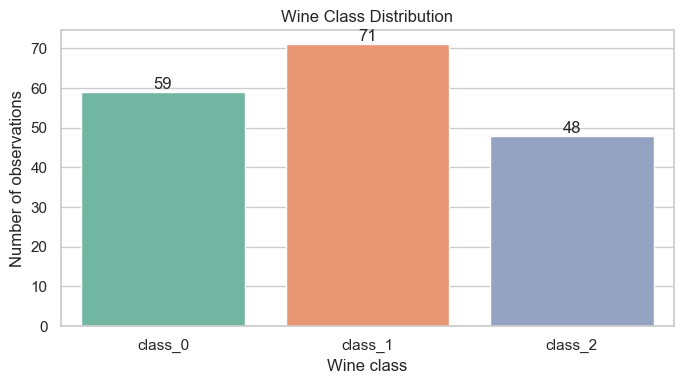

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=data, x="class_name", hue="class_name", palette="Set2", legend=False, ax=ax)
ax.set(title="Wine Class Distribution", xlabel="Wine class", ylabel="Number of observations")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

The dataset has 178 complete observations, 13 numeric chemical features, and three somewhat imbalanced classes. The feature summary also shows very different numeric ranges—for example, `proline` is measured in the hundreds while several other variables are single-digit values. This matters for all distance-based classifiers.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

split_summary = pd.DataFrame({
    "training": y_train.value_counts().sort_index(),
    "testing": y_test.value_counts().sort_index(),
}).rename(index=class_names)

print(f"Training set: {X_train.shape[0]} observations ({X_train.shape[0] / len(X):.0%})")
print(f"Testing set:  {X_test.shape[0]} observations ({X_test.shape[0] / len(X):.0%})")
display(split_summary)

Training set: 142 observations (80%)
Testing set:  36 observations (20%)


,training,testing
target,,
class_0,47,12
class_1,57,14
class_2,38,10


## 2. K-Nearest Neighbors (KNN)

For each assigned value of `k`, the classifier predicts a test observation using the majority class among its `k` closest training observations.

In [6]:
k_values = [1, 5, 11, 15, 21]
knn_records = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    knn_records.append({"k": k, "accuracy": accuracy_score(y_test, predictions)})

knn_results = pd.DataFrame(knn_records)
display(knn_results.style.format({"accuracy": "{:.2%}"}).hide(axis="index"))

k,accuracy
1,77.78%
5,80.56%
11,80.56%
15,80.56%
21,80.56%


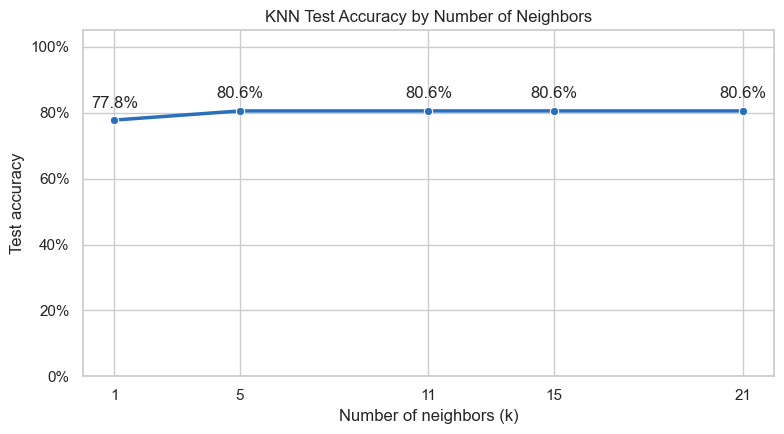

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=knn_results, x="k", y="accuracy", marker="o", linewidth=2.5, color="#2a6fbb", ax=ax)
ax.set(
    title="KNN Test Accuracy by Number of Neighbors",
    xlabel="Number of neighbors (k)",
    ylabel="Test accuracy",
    xticks=k_values,
    ylim=(0, 1.05),
)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
for row in knn_results.itertuples():
    ax.annotate(f"{row.accuracy:.1%}", (row.k, row.accuracy), xytext=(0, 9), textcoords="offset points", ha="center")
plt.tight_layout()
plt.show()

## 3. Radius Neighbors (RNN)

RNN uses every training observation within the specified radius. Along with accuracy, the table reports the smallest number of neighbors found for any test observation and the number of test observations with no neighbors. The `outlier_label='most_frequent'` safeguard makes prediction defined if a radius leaves an observation without neighbors; the diagnostic columns reveal whether that safeguard was actually needed.

In [8]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_records = []

for radius in radius_values:
    model = RadiusNeighborsClassifier(radius=radius, outlier_label="most_frequent")
    model.fit(X_train, y_train)
    neighbor_indices = model.radius_neighbors(X_test, return_distance=False)
    neighbor_counts = pd.Series([len(indices) for indices in neighbor_indices])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        predictions = model.predict(X_test)
    rnn_records.append({
        "radius": radius,
        "accuracy": accuracy_score(y_test, predictions),
        "minimum_neighbors": int(neighbor_counts.min()),
        "test_points_without_neighbors": int((neighbor_counts == 0).sum()),
    })

rnn_results = pd.DataFrame(rnn_records)
display(rnn_results.style.format({"accuracy": "{:.2%}"}).hide(axis="index"))

radius,accuracy,minimum_neighbors,test_points_without_neighbors
350,72.22%,4,0
400,69.44%,9,0
450,69.44%,14,0
500,69.44%,17,0
550,66.67%,19,0
600,66.67%,23,0


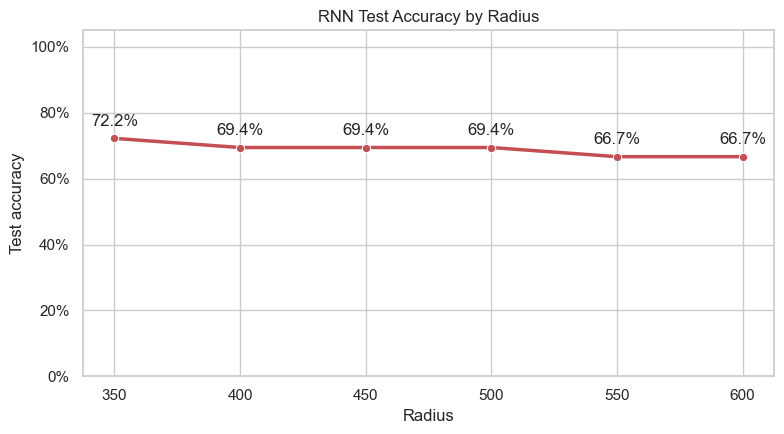

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=rnn_results, x="radius", y="accuracy", marker="o", linewidth=2.5, color="#c44e52", ax=ax)
ax.set(
    title="RNN Test Accuracy by Radius",
    xlabel="Radius",
    ylabel="Test accuracy",
    xticks=radius_values,
    ylim=(0, 1.05),
)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
for row in rnn_results.itertuples():
    ax.annotate(f"{row.accuracy:.1%}", (row.radius, row.accuracy), xytext=(0, 9), textcoords="offset points", ha="center")
plt.tight_layout()
plt.show()

## 4. Compare the models

In [10]:
best_knn = knn_results.loc[knn_results["accuracy"].idxmax()]
best_rnn = rnn_results.loc[rnn_results["accuracy"].idxmax()]
comparison = pd.DataFrame([
    {"model": "KNN", "best_parameter": f"k={int(best_knn['k'])}", "test_accuracy": best_knn["accuracy"]},
    {"model": "RNN", "best_parameter": f"radius={int(best_rnn['radius'])}", "test_accuracy": best_rnn["accuracy"]},
])
display(comparison.style.format({"test_accuracy": "{:.2%}"}).hide(axis="index"))

winner = comparison.loc[comparison["test_accuracy"].idxmax(), "model"]
print(f"Best KNN: k={int(best_knn['k'])}, accuracy={best_knn['accuracy']:.2%}")
print(f"Best RNN: radius={int(best_rnn['radius'])}, accuracy={best_rnn['accuracy']:.2%}")
print(f"Highest observed test accuracy: {winner}")

model,best_parameter,test_accuracy
KNN,k=5,80.56%
RNN,radius=350,72.22%


Best KNN: k=5, accuracy=80.56%
Best RNN: radius=350, accuracy=72.22%
Highest observed test accuracy: KNN


### Results, observations, and model choice

- **Observed performance:** KNN scored 77.78% at `k=1` and 80.56% at each of `k=5`, `11`, `15`, and `21`. Therefore, the tested KNN values tie from `k=5` onward, and `k=5` is reported as the best value because it is the first value achieving the maximum. RNN was best at radius 350 with 72.22% accuracy, declined to 69.44% for radii 400–500, and declined again to 66.67% for radii 550–600. None of the tested RNN settings left a test point without neighbors.
- **Parameter sensitivity:** Changing `k` changes the balance between a flexible boundary (small `k`) and a smoother boundary (large `k`). In this split, increasing `k` from 1 to 5 helped, while later values produced a plateau. Increasing the RNN radius included progressively more distant points, blurred class boundaries, and reduced accuracy.
- **Direct comparison:** The best tested KNN accuracy exceeded the best tested RNN accuracy by 8.33 percentage points (80.56% versus 72.22%). KNN was therefore preferable for this dataset, split, and assigned parameter grid.
- **When KNN is preferable:** KNN is useful when every query must receive a prediction and local sample density varies. Its fixed neighbor count makes behavior relatively predictable, though a very small `k` can be noisy and a very large `k` can underfit.
- **When RNN is preferable:** RNN is useful when a meaningful distance threshold exists and the number of relevant neighbors should adapt to local density. It can identify unsupported observations (zero neighbors), but radius selection is sensitive to feature scale and sparse regions.
- **Interpretation caution:** These figures describe one held-out test split and the required raw-scale parameter grid. They are not proof of generalization. A stronger follow-up would put `StandardScaler` and the classifier in a pipeline, tune parameters using stratified cross-validation on the training set, and evaluate the chosen model once on the untouched test set.